In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("whatsapp.txt",header=None,on_bad_lines='skip',encoding='utf8')
df

,0,1,2
0,1/3/26,1:05 AM - Sathish Uma: Hi Mam,How are you!
1,1/3/26,1:06 AM - Sathish Uma: I have completed the M...,NaN
2,1/3/26,1:07 AM - Sathish Uma: I have some doubts in ...,NaN
3,1/3/26,2:22 AM - Sathish Uma: https://github.com/Uma...,NaN
4,1/3/26,2:23 AM - Sathish Uma: Python debugging set1 Mam,NaN
...,...,...,...
56,1/7/26,11:12 AM - Sathish Uma: Okay mam,NaN
57,1/7/26,12:31 PM - Rubhini Hope AI: I was in a other ...,NaN
58,1/7/26,3:24 PM - Sathish Uma: Sure Mam,welcome
59,1/7/26,3:29 PM - Sathish Uma: Got it Mam,thank you


In [3]:
df.columns=["Date","Chat","chat1"]
message=df["Chat"].str.split('-',n=1,expand=True)
message1=message[1].str.split(':',n=1,expand=True)
df["Time"]=message[0]
df["Name"]=message1[0]
df["Chat"]=message1[1]
df=df.drop(columns=["chat1"])

In [4]:
dataset=df[["Date","Time",'Name','Chat']]

In [5]:
dataset

,Date,Time,Name,Chat
0,1/3/26,1:05 AM,Sathish Uma,Hi Mam
1,1/3/26,1:06 AM,Sathish Uma,I have completed the MCQ python test
2,1/3/26,1:07 AM,Sathish Uma,I have some doubts in python interview questi...
3,1/3/26,2:22 AM,Sathish Uma,https://github.com/Uma761995/Python-Debug/blo...
4,1/3/26,2:23 AM,Sathish Uma,Python debugging set1 Mam
...,...,...,...,...
56,1/7/26,11:12 AM,Sathish Uma,Okay mam
57,1/7/26,12:31 PM,Rubhini Hope AI,I was in a other call... Reach you mam
58,1/7/26,3:24 PM,Sathish Uma,Sure Mam
59,1/7/26,3:29 PM,Sathish Uma,Got it Mam


In [6]:
dataset.dropna(inplace=True)

C:\Users\Sathish\AppData\Local\Temp\ipykernel_7668\2639109627.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataset.dropna(inplace=True)


Sentimental Analysis

In [7]:
def sentimentAnalysis(data,columnname):
    import nltk
    from nltk.sentiment.vader import SentimentIntensityAnalyzer
    nltk.download('vader_lexicon')
    import matplotlib.pyplot as plt
    import seaborn as sns
    sid=SentimentIntensityAnalyzer()

    data['score']=data[columnname].apply(lambda commonText:sid.polarity_scores(commonText))
    data['compound']=data['score'].apply(lambda score_dict:score_dict['compound'])
    data['positive']=data['score'].apply(lambda score_dict:score_dict['pos'])
    data['negative']=data['score'].apply(lambda score_dict:score_dict['neg'])
    data['neutral']=data['score'].apply(lambda score_dict:score_dict['neu'])
    data["comp_score"]=data["compound"].apply (lambda c: 'pos' if c>=0 else 'neg')
    plt.clf

    posneg=pd.DataFrame( data["comp_score"].value_counts())
    return data, posneg

In [8]:
pos,data_Senti=sentimentAnalysis(dataset,columnname='Chat')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\Sathish\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!
C:\Users\Sathish\AppData\Local\Temp\ipykernel_7668\1975584284.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['score']=data[columnname].apply(lambda commonText:sid.polarity_scores(commonText))
C:\Users\Sathish\AppData\Local\Temp\ipykernel_7668\1975584284.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['compound']=data['sc

In [9]:
data_Senti

,count
comp_score,
pos,58
neg,2


In [10]:
pos

,Date,Time,Name,Chat,score,compound,positive,negative,neutral,comp_score
0,1/3/26,1:05 AM,Sathish Uma,Hi Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
1,1/3/26,1:06 AM,Sathish Uma,I have completed the MCQ python test,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
2,1/3/26,1:07 AM,Sathish Uma,I have some doubts in python interview questi...,"{'neg': 0.18, 'neu': 0.82, 'pos': 0.0, 'compou...",-0.2960,0.000,0.180,0.820,neg
3,1/3/26,2:22 AM,Sathish Uma,https://github.com/Uma761995/Python-Debug/blo...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
4,1/3/26,2:23 AM,Sathish Uma,Python debugging set1 Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos
5,1/3/26,9:11 AM,Rubhini Hope AI,Fine! Hope you're fine,"{'neg': 0.0, 'neu': 0.128, 'pos': 0.872, 'comp...",0.6996,0.872,0.000,0.128,pos
6,1/3/26,9:12 AM,Rubhini Hope AI,Okay mam,"{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'comp...",0.2263,0.655,0.000,0.345,pos
7,1/3/26,10:26 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos
8,1/5/26,11:19 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos
9,1/5/26,11:19 AM,Sathish Uma,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.730,0.000,0.270,pos


Topic Modelling -->This is unsupervised learning. -->group the max topic from the input (pdf file, chat) and give the result

In [11]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.decomposition import NMF
from sklearn.decomposition import LatentDirichletAllocation  

In [12]:
def count_tfidf(data,columnname,vectorizer,topicmodel):
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
    from sklearn.decomposition import NMF
    from sklearn.decomposition import LatentDirichletAllocation  
    vector=vectorizer(max_df=0.95, min_df=2,stop_words='english')
    vec=vector.fit_transform(data[columnname])
      
    model=topicmodel(n_components=5,random_state=42)
    model.fit(vec)
    for index,topic in enumerate(model.components_):  
        results=([vector.get_feature_names_out()[i] for i in topic.argsort()[-10:]])  
        print(f"Topic{index}:{results}")
    topic_result=model.transform(vec)
    data["Topic"]=topic_result.argmax(axis=1)
    counts=data["Topic"].value_counts()
    
    return data,counts

In [13]:
dataset_topic,count=count_tfidf(dataset,columnname="Chat",vectorizer=TfidfVectorizer,topicmodel=NMF)
print(count)

Topic0:['python', 'completed', 'set', 'question', 'set2', 'scenario', 'set1', 'thank', 'mam', 'okay']
Topic1:['number', 'share', 'fine', 'reach', 'code', 'got', 'hi', 'yes', 'sure', 'mam']
Topic2:['https', 'blob', 'com', 'uma761995', 'github', 'debug', '20', 'set1', 'scenario', 'python']
Topic3:['share', 'string', 'scenario', 'question', 'set', 'completed', 'set2', 'mam', 'thank', 'ok']
Topic4:['sure', 'string', 'share', 'uma761995', 'value', 'yes', 'thank', 'mam', 'python', 'interview']
Topic
1    24
0    15
2    12
3     6
4     3
Name: count, dtype: int64


C:\Users\Sathish\AppData\Local\Temp\ipykernel_7668\1434314872.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Topic"]=topic_result.argmax(axis=1)


In [14]:
dataset_topic  #vectorizer=TfidfVectorizer, topic_model=NMF

,Date,Time,Name,Chat,score,compound,positive,negative,neutral,comp_score,Topic
0,1/3/26,1:05 AM,Sathish Uma,Hi Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,1
1,1/3/26,1:06 AM,Sathish Uma,I have completed the MCQ python test,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
2,1/3/26,1:07 AM,Sathish Uma,I have some doubts in python interview questi...,"{'neg': 0.18, 'neu': 0.82, 'pos': 0.0, 'compou...",-0.2960,0.000,0.180,0.820,neg,4
3,1/3/26,2:22 AM,Sathish Uma,https://github.com/Uma761995/Python-Debug/blo...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
4,1/3/26,2:23 AM,Sathish Uma,Python debugging set1 Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
5,1/3/26,9:11 AM,Rubhini Hope AI,Fine! Hope you're fine,"{'neg': 0.0, 'neu': 0.128, 'pos': 0.872, 'comp...",0.6996,0.872,0.000,0.128,pos,1
6,1/3/26,9:12 AM,Rubhini Hope AI,Okay mam,"{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'comp...",0.2263,0.655,0.000,0.345,pos,0
7,1/3/26,10:26 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,1
8,1/5/26,11:19 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,1
9,1/5/26,11:19 AM,Sathish Uma,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.730,0.000,0.270,pos,1


In [15]:
dataset_topic,count=count_tfidf(dataset,columnname="Chat",vectorizer=CountVectorizer,topicmodel=NMF)
print(count)

Topic0:['ipynb', 'blob', 'com', 'https', 'github', 'uma761995', 'main', 'debug', '20', 'python']
Topic1:['hi', 'reach', 'python', 'code', 'share', 'sure', 'thank', 'yes', 'ok', 'mam']
Topic2:['20', 'blob', 'github', 'https', 'com', 'uma761995', 'main', 'python', 'docx', 'scenario']
Topic3:['completed', 'set2', 'question', 'set', 'prime', 'fine', 'interview', 'thank', 'mam', 'okay']
Topic4:['sure', 'string', 'share', 'uma761995', 'value', 'yes', 'thank', 'mam', 'prime', 'number']
Topic
1    31
3    11
0     8
2     8
4     2
Name: count, dtype: int64


C:\Users\Sathish\AppData\Local\Temp\ipykernel_7668\1434314872.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Topic"]=topic_result.argmax(axis=1)


In [16]:
dataset_topic  #vectorizer=CountVectorizer, topic_model=NMF

,Date,Time,Name,Chat,score,compound,positive,negative,neutral,comp_score,Topic
0,1/3/26,1:05 AM,Sathish Uma,Hi Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,1
1,1/3/26,1:06 AM,Sathish Uma,I have completed the MCQ python test,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
2,1/3/26,1:07 AM,Sathish Uma,I have some doubts in python interview questi...,"{'neg': 0.18, 'neu': 0.82, 'pos': 0.0, 'compou...",-0.2960,0.000,0.180,0.820,neg,0
3,1/3/26,2:22 AM,Sathish Uma,https://github.com/Uma761995/Python-Debug/blo...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
4,1/3/26,2:23 AM,Sathish Uma,Python debugging set1 Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,1
5,1/3/26,9:11 AM,Rubhini Hope AI,Fine! Hope you're fine,"{'neg': 0.0, 'neu': 0.128, 'pos': 0.872, 'comp...",0.6996,0.872,0.000,0.128,pos,1
6,1/3/26,9:12 AM,Rubhini Hope AI,Okay mam,"{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'comp...",0.2263,0.655,0.000,0.345,pos,3
7,1/3/26,10:26 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,1
8,1/5/26,11:19 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,1
9,1/5/26,11:19 AM,Sathish Uma,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.730,0.000,0.270,pos,1


In [17]:
dataset_topic,count=count_tfidf(dataset,columnname="Chat",vectorizer=CountVectorizer,topicmodel=LatentDirichletAllocation)
print(count)

Topic0:['https', 'com', 'blob', 'uma761995', 'completed', 'fine', 'number', 'debug', '20', 'python']
Topic1:['message', 'value', 'reach', 'python', 'set1', 'string', 'share', 'yes', 'code', 'mam']
Topic2:['share', 'reach', 'yes', 'got', 'hi', 'sure', 'ok', 'thank', 'okay', 'mam']
Topic3:['message', 'remaining', 'yes', 'reach', 'string', 'mam', 'python', 'know', 'value', 'interview']
Topic4:['github', 'main', 'blob', 'https', 'com', 'uma761995', 'logic', 'docx', 'python', 'scenario']
Topic
2    30
0    12
4     9
3     5
1     4
Name: count, dtype: int64


C:\Users\Sathish\AppData\Local\Temp\ipykernel_7668\1434314872.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Topic"]=topic_result.argmax(axis=1)


In [18]:
dataset_topic  #vectorizer=CountVectorizer, topic_model=LatentDirichletAllocation

,Date,Time,Name,Chat,score,compound,positive,negative,neutral,comp_score,Topic
0,1/3/26,1:05 AM,Sathish Uma,Hi Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
1,1/3/26,1:06 AM,Sathish Uma,I have completed the MCQ python test,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
2,1/3/26,1:07 AM,Sathish Uma,I have some doubts in python interview questi...,"{'neg': 0.18, 'neu': 0.82, 'pos': 0.0, 'compou...",-0.2960,0.000,0.180,0.820,neg,3
3,1/3/26,2:22 AM,Sathish Uma,https://github.com/Uma761995/Python-Debug/blo...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
4,1/3/26,2:23 AM,Sathish Uma,Python debugging set1 Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,1
5,1/3/26,9:11 AM,Rubhini Hope AI,Fine! Hope you're fine,"{'neg': 0.0, 'neu': 0.128, 'pos': 0.872, 'comp...",0.6996,0.872,0.000,0.128,pos,0
6,1/3/26,9:12 AM,Rubhini Hope AI,Okay mam,"{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'comp...",0.2263,0.655,0.000,0.345,pos,2
7,1/3/26,10:26 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,2
8,1/5/26,11:19 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,2
9,1/5/26,11:19 AM,Sathish Uma,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.730,0.000,0.270,pos,2


In [19]:
dataset_topic,count=count_tfidf(dataset,columnname="Chat",vectorizer=TfidfVectorizer,topicmodel=LatentDirichletAllocation)
print(count)

Topic0:['debug', 'prime', '20', 'number', 'scenario', 'fine', 'mam', 'completed', 'python', 'sure']
Topic1:['mam', 'scenario', 'yes', 'know', 'logic', 'question', 'remaining', 'share', 'string', 'code']
Topic2:['share', 'code', 'thank', 'reach', 'hi', 'got', 'yes', 'ok', 'okay', 'mam']
Topic3:['string', 'scenario', 'remaining', 'yes', 'reach', 'mam', 'python', 'know', 'value', 'interview']
Topic4:['reach', 'scenario', 'value', 'string', 'll', 'python', 'set1', 'message', 'mam', 'thank']
Topic
2    25
0    19
4     7
3     5
1     4
Name: count, dtype: int64


C:\Users\Sathish\AppData\Local\Temp\ipykernel_7668\1434314872.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Topic"]=topic_result.argmax(axis=1)


In [20]:
dataset_topic  #vectorizer=TfidfVectorizer,topic_model=LatentDirichletAllocation

,Date,Time,Name,Chat,score,compound,positive,negative,neutral,comp_score,Topic
0,1/3/26,1:05 AM,Sathish Uma,Hi Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
1,1/3/26,1:06 AM,Sathish Uma,I have completed the MCQ python test,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
2,1/3/26,1:07 AM,Sathish Uma,I have some doubts in python interview questi...,"{'neg': 0.18, 'neu': 0.82, 'pos': 0.0, 'compou...",-0.2960,0.000,0.180,0.820,neg,3
3,1/3/26,2:22 AM,Sathish Uma,https://github.com/Uma761995/Python-Debug/blo...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
4,1/3/26,2:23 AM,Sathish Uma,Python debugging set1 Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,4
5,1/3/26,9:11 AM,Rubhini Hope AI,Fine! Hope you're fine,"{'neg': 0.0, 'neu': 0.128, 'pos': 0.872, 'comp...",0.6996,0.872,0.000,0.128,pos,0
6,1/3/26,9:12 AM,Rubhini Hope AI,Okay mam,"{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'comp...",0.2263,0.655,0.000,0.345,pos,2
7,1/3/26,10:26 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,0
8,1/5/26,11:19 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,0
9,1/5/26,11:19 AM,Sathish Uma,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.730,0.000,0.270,pos,2


In [21]:
def hash_vector(data,columnname,vectorizer,topicmodel):
    from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
    from sklearn.decomposition import NMF
    from sklearn.decomposition import LatentDirichletAllocation  
    vector=vectorizer(n_features=1000,ngram_range=(1,2),stop_words='english', alternate_sign=False)
    vec=vector.fit_transform(data[columnname])
      
    model=topicmodel(n_components=5,random_state=42)
    model.fit(vec)
    
    topic_result=model.transform(vec)
    data["Topic"]=topic_result.argmax(axis=1)
    counts=data["Topic"].value_counts()
    
    return data,counts

In [22]:
dataset_topic,count=hash_vector(dataset,columnname="Chat",vectorizer=HashingVectorizer,topicmodel=NMF)
print(count)

Topic
0    22
2    17
1    12
3     6
4     3
Name: count, dtype: int64


C:\Users\Sathish\AppData\Local\Temp\ipykernel_7668\1979343673.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Topic"]=topic_result.argmax(axis=1)


In [23]:
dataset_topic  #vectorizer=HashingVectorizer, topic_model=NMF

,Date,Time,Name,Chat,score,compound,positive,negative,neutral,comp_score,Topic
0,1/3/26,1:05 AM,Sathish Uma,Hi Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
1,1/3/26,1:06 AM,Sathish Uma,I have completed the MCQ python test,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
2,1/3/26,1:07 AM,Sathish Uma,I have some doubts in python interview questi...,"{'neg': 0.18, 'neu': 0.82, 'pos': 0.0, 'compou...",-0.2960,0.000,0.180,0.820,neg,2
3,1/3/26,2:22 AM,Sathish Uma,https://github.com/Uma761995/Python-Debug/blo...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
4,1/3/26,2:23 AM,Sathish Uma,Python debugging set1 Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,2
5,1/3/26,9:11 AM,Rubhini Hope AI,Fine! Hope you're fine,"{'neg': 0.0, 'neu': 0.128, 'pos': 0.872, 'comp...",0.6996,0.872,0.000,0.128,pos,0
6,1/3/26,9:12 AM,Rubhini Hope AI,Okay mam,"{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'comp...",0.2263,0.655,0.000,0.345,pos,1
7,1/3/26,10:26 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,4
8,1/5/26,11:19 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,4
9,1/5/26,11:19 AM,Sathish Uma,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.730,0.000,0.270,pos,0


In [24]:
dataset_topic,count=hash_vector(dataset,columnname="Chat",vectorizer=HashingVectorizer,topicmodel=LatentDirichletAllocation)
print(count)

Topic
0    39
2    10
3     5
1     4
4     2
Name: count, dtype: int64


C:\Users\Sathish\AppData\Local\Temp\ipykernel_7668\1979343673.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data["Topic"]=topic_result.argmax(axis=1)


In [25]:
dataset_topic  #vectorizer=HashingVectorizer, topic_model=LatentDirichletAllocation

,Date,Time,Name,Chat,score,compound,positive,negative,neutral,comp_score,Topic
0,1/3/26,1:05 AM,Sathish Uma,Hi Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,0
1,1/3/26,1:06 AM,Sathish Uma,I have completed the MCQ python test,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,3
2,1/3/26,1:07 AM,Sathish Uma,I have some doubts in python interview questi...,"{'neg': 0.18, 'neu': 0.82, 'pos': 0.0, 'compou...",-0.2960,0.000,0.180,0.820,neg,3
3,1/3/26,2:22 AM,Sathish Uma,https://github.com/Uma761995/Python-Debug/blo...,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,1
4,1/3/26,2:23 AM,Sathish Uma,Python debugging set1 Mam,"{'neg': 0.0, 'neu': 1.0, 'pos': 0.0, 'compound...",0.0000,0.000,0.000,1.000,pos,1
5,1/3/26,9:11 AM,Rubhini Hope AI,Fine! Hope you're fine,"{'neg': 0.0, 'neu': 0.128, 'pos': 0.872, 'comp...",0.6996,0.872,0.000,0.128,pos,4
6,1/3/26,9:12 AM,Rubhini Hope AI,Okay mam,"{'neg': 0.0, 'neu': 0.345, 'pos': 0.655, 'comp...",0.2263,0.655,0.000,0.345,pos,0
7,1/3/26,10:26 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,0
8,1/5/26,11:19 AM,Sathish Uma,Sure Mam,"{'neg': 0.0, 'neu': 0.303, 'pos': 0.697, 'comp...",0.3182,0.697,0.000,0.303,pos,0
9,1/5/26,11:19 AM,Sathish Uma,Yes Mam,"{'neg': 0.0, 'neu': 0.27, 'pos': 0.73, 'compou...",0.4019,0.730,0.000,0.270,pos,0


WordCloud

In [28]:
from wordcloud import WordCloud
from nltk.corpus import stopwords
import nltk
import matplotlib.pyplot as plt
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Sathish\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [30]:
vv = " ".join(dataset["Chat"].dropna().astype(str))

wordcloud = WordCloud(
    width=800,
    height=800,
    background_color="white",
    
    min_font_size=10
).generate(vv)

In [31]:
vv

" Hi Mam  I have completed the MCQ python test  I have some doubts in python interview questions will connect you tomorrow  https://github.com/Uma761995/Python-Debug/blob/main/python%20-Debug%20..ipynb  Python debugging set1 Mam  Fine! Hope you're fine  Okay mam  Sure Mam  Sure Mam  Yes Mam  https://github.com/Uma761995/Python-Debug-Set1/blob/main/python%20-Debug%20..ipynb  Home tab mam?  Ok mam  Okay mam  Done Mam  Mam please explain prime number and factorial  Yes mam...code snippet share pannunga  Prime number is a number greater than 1 that has only two factors  Solved Mam  To place the value stored in that 'num' variable we'll use *f string*  F is for?  f is for?  F is formatted string literal  Okay mam  ASCII default value of A is 65!  Yes mam  Okay mam thank you  Well done👏👏  Thank you Mam  Thank you Mam  I'm in a interview meet mam  Okay Mam  Mam I have completed scenario question for set 1   Remaining i have completed  Okay mam...  Will review it  Got it Mam  Share a voice not

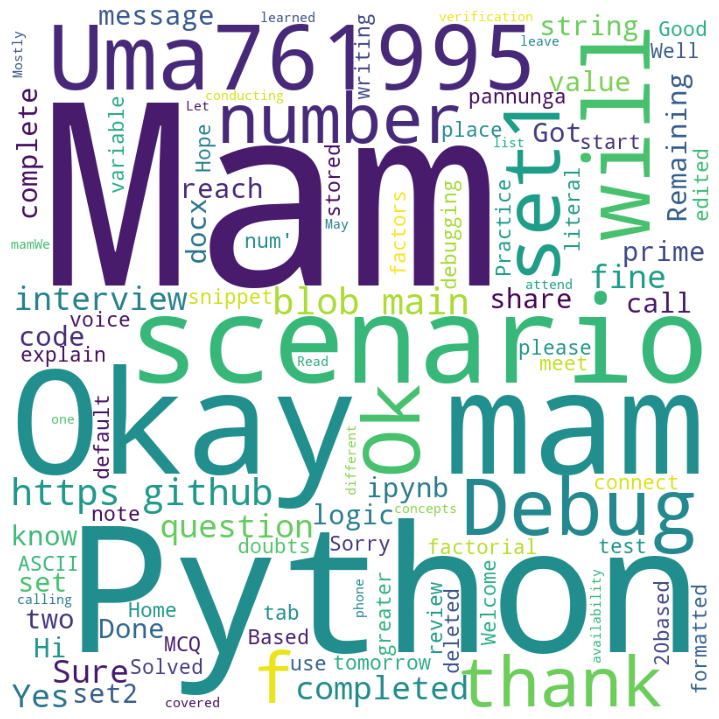

Successfully created


In [32]:
plt.figure(figsize = (9, 7), facecolor = None)
plt.imshow(wordcloud)
plt.axis("off") 
plt.tight_layout(pad = 0) 
plt.savefig('wordcloud.PNG')
plt.show() 
print("Successfully created")
wordcloudss="This function saves image"
